In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/summer-olympic-medals/Summer-Olympic-medals-1976-to-2008.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

## **Note- IF CSV NOT Encoded by utf 8 then use  encoding='latin1'**

## **1.Dataset Loading**

In [3]:
df=pd.read_csv('/kaggle/input/summer-olympic-medals/Summer-Olympic-medals-1976-to-2008.csv',encoding='latin1')

In [4]:
df.head(6)

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
0,Montreal,1976.0,Aquatics,Diving,3m springboard,"KÖHLER, Christa",Women,GDR,East Germany,W,Silver
1,Montreal,1976.0,Aquatics,Diving,3m springboard,"KOSENKOV, Aleksandr",Men,URS,Soviet Union,M,Bronze
2,Montreal,1976.0,Aquatics,Diving,3m springboard,"BOGGS, Philip George",Men,USA,United States,M,Gold
3,Montreal,1976.0,Aquatics,Diving,3m springboard,"CAGNOTTO, Giorgio Franco",Men,ITA,Italy,M,Silver
4,Montreal,1976.0,Aquatics,Diving,10m platform,"WILSON, Deborah Keplar",Women,USA,United States,W,Bronze
5,Montreal,1976.0,Aquatics,Diving,10m platform,"LOUGANIS, Gregory",Men,USA,United States,M,Silver


In [5]:
df.info()
## Medal is a target variable

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15433 entries, 0 to 15432
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   City          15316 non-null  object 
 1   Year          15316 non-null  float64
 2   Sport         15316 non-null  object 
 3   Discipline    15316 non-null  object 
 4   Event         15316 non-null  object 
 5   Athlete       15316 non-null  object 
 6   Gender        15316 non-null  object 
 7   Country_Code  15316 non-null  object 
 8   Country       15316 non-null  object 
 9   Event_gender  15316 non-null  object 
 10  Medal         15316 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.3+ MB


In [6]:
df['Medal'].unique()

array(['Silver', 'Bronze', 'Gold', nan], dtype=object)

## **It is Classification Problem**

In [7]:
df.describe()

,Year
count,15316.000000
mean,1993.620789
std,10.159851
min,1976.000000
25%,1984.000000
50%,1996.000000
75%,2004.000000
max,2008.000000


In [8]:
## Basic Check for null Values
df.isnull().sum()

City            117
Year            117
Sport           117
Discipline      117
Event           117
Athlete         117
Gender          117
Country_Code    117
Country         117
Event_gender    117
Medal           117
dtype: int64

## **2.EDA**

le=LabelEncoder()
df['Medal']=le.fit_transform(df['Medal'])

In [9]:
df.head(5)

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
0,Montreal,1976.0,Aquatics,Diving,3m springboard,"KÖHLER, Christa",Women,GDR,East Germany,W,Silver
1,Montreal,1976.0,Aquatics,Diving,3m springboard,"KOSENKOV, Aleksandr",Men,URS,Soviet Union,M,Bronze
2,Montreal,1976.0,Aquatics,Diving,3m springboard,"BOGGS, Philip George",Men,USA,United States,M,Gold
3,Montreal,1976.0,Aquatics,Diving,3m springboard,"CAGNOTTO, Giorgio Franco",Men,ITA,Italy,M,Silver
4,Montreal,1976.0,Aquatics,Diving,10m platform,"WILSON, Deborah Keplar",Women,USA,United States,W,Bronze


In [10]:
df=df.dropna()

In [11]:
df.isnull().sum()

City            0
Year            0
Sport           0
Discipline      0
Event           0
Athlete         0
Gender          0
Country_Code    0
Country         0
Event_gender    0
Medal           0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15316 entries, 0 to 15432
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   City          15316 non-null  object 
 1   Year          15316 non-null  float64
 2   Sport         15316 non-null  object 
 3   Discipline    15316 non-null  object 
 4   Event         15316 non-null  object 
 5   Athlete       15316 non-null  object 
 6   Gender        15316 non-null  object 
 7   Country_Code  15316 non-null  object 
 8   Country       15316 non-null  object 
 9   Event_gender  15316 non-null  object 
 10  Medal         15316 non-null  object 
dtypes: float64(1), object(10)
memory usage: 1.4+ MB


In [13]:
df['Medal'].value_counts()

Medal
Bronze    5258
Gold      5042
Silver    5016
Name: count, dtype: int64

In [14]:
le=LabelEncoder()
df['Medal']=le.fit_transform(df['Medal'])

In [15]:
df.head(5)

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender,Medal
0,Montreal,1976.0,Aquatics,Diving,3m springboard,"KÖHLER, Christa",Women,GDR,East Germany,W,2
1,Montreal,1976.0,Aquatics,Diving,3m springboard,"KOSENKOV, Aleksandr",Men,URS,Soviet Union,M,0
2,Montreal,1976.0,Aquatics,Diving,3m springboard,"BOGGS, Philip George",Men,USA,United States,M,1
3,Montreal,1976.0,Aquatics,Diving,3m springboard,"CAGNOTTO, Giorgio Franco",Men,ITA,Italy,M,2
4,Montreal,1976.0,Aquatics,Diving,10m platform,"WILSON, Deborah Keplar",Women,USA,United States,W,0


In [16]:
X=df.drop(columns=['Medal'])
y=df['Medal']

In [17]:
X.sample(5)

,City,Year,Sport,Discipline,Event,Athlete,Gender,Country_Code,Country,Event_gender
5703,Seoul,1988.0,Volleyball,Volleyball,volleyball,"FAJARDO, Denisse",Women,PER,Peru,W
3146,Los Angeles,1984.0,Athletics,Athletics,3000m steeplechase,"MAHMOUD, Joseph",Men,FRA,France,M
5443,Seoul,1988.0,Rowing,Rowing,eight with coxswain (8+),"DOMAIN, Thomas",Men,FRG,West Germany,M
6538,Barcelona,1992.0,Cycling,Cycling Road,team time trial,"COLOMBO, Luca",Men,ITA,Italy,M
5233,Seoul,1988.0,Hockey,Hockey,hockey,"SEO, Hyo-Sun",Women,KOR,"Korea, South",W


In [18]:
y.sample(5)

8374     1
11616    2
2423     0
13245    0
8587     0
Name: Medal, dtype: int64

In [19]:
X.columns

Index(['City', 'Year', 'Sport', 'Discipline', 'Event', 'Athlete', 'Gender',
       'Country_Code', 'Country', 'Event_gender'],
      dtype='object')

In [20]:
X['Year']=X['Year'].astype(int)

In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15316 entries, 0 to 15432
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   City          15316 non-null  object
 1   Year          15316 non-null  int64 
 2   Sport         15316 non-null  object
 3   Discipline    15316 non-null  object
 4   Event         15316 non-null  object
 5   Athlete       15316 non-null  object
 6   Gender        15316 non-null  object
 7   Country_Code  15316 non-null  object
 8   Country       15316 non-null  object
 9   Event_gender  15316 non-null  object
dtypes: int64(1), object(9)
memory usage: 1.3+ MB


In [22]:
X.dtypes

City            object
Year             int64
Sport           object
Discipline      object
Event           object
Athlete         object
Gender          object
Country_Code    object
Country         object
Event_gender    object
dtype: object

In [23]:
X.select_dtypes(['int64'])

,Year
0,1976
1,1976
2,1976
3,1976
4,1976
...,...
15428,2008
15429,2008
15430,2008
15431,2008


## **Numerical Column**

 Numerical Column:Year


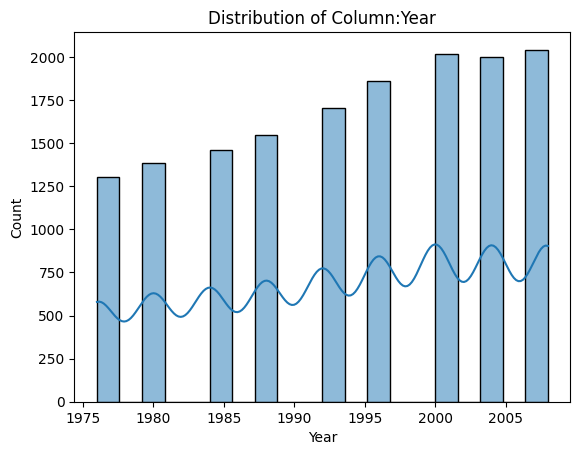

In [24]:
for col in X.select_dtypes(['int64']):
    print(f" Numerical Column:{col}")
    plt.figure()

    sns.histplot(X[col],kde=True)
    plt.title(f"Distribution of Column:{col}")
    plt.show()

In [25]:
X['City'].value_counts()

City
Beijing        2042
Sydney         2015
Athens         1998
Atlanta        1859
Barcelona      1705
Seoul          1546
Los Angeles    1459
Moscow         1387
Montreal       1305
Name: count, dtype: int64

In [26]:
X['Gender'].value_counts()

Gender
Men      9388
Women    5928
Name: count, dtype: int64

## **Categorical Column**

 Categorical Column:City


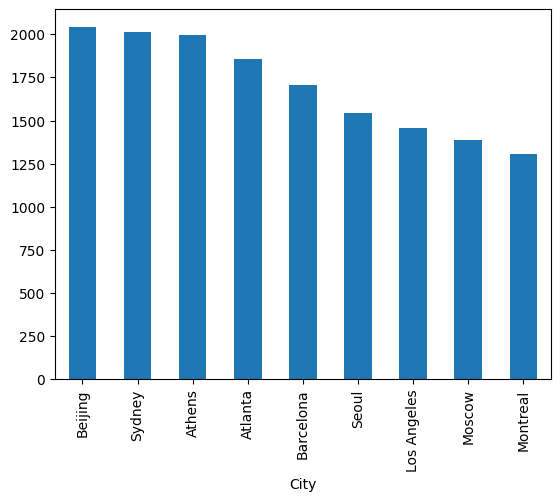

 Categorical Column:Sport


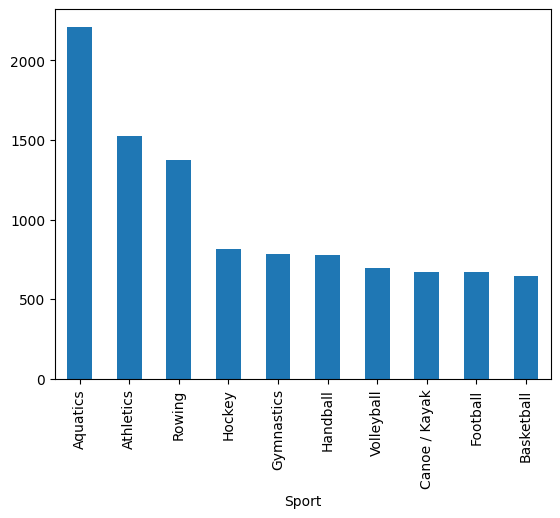

 Categorical Column:Discipline


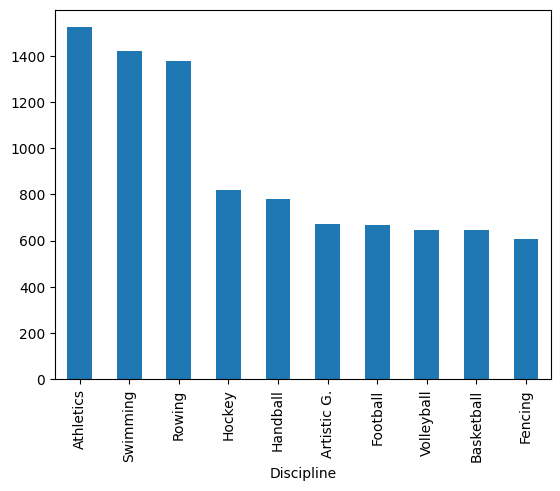

 Categorical Column:Event


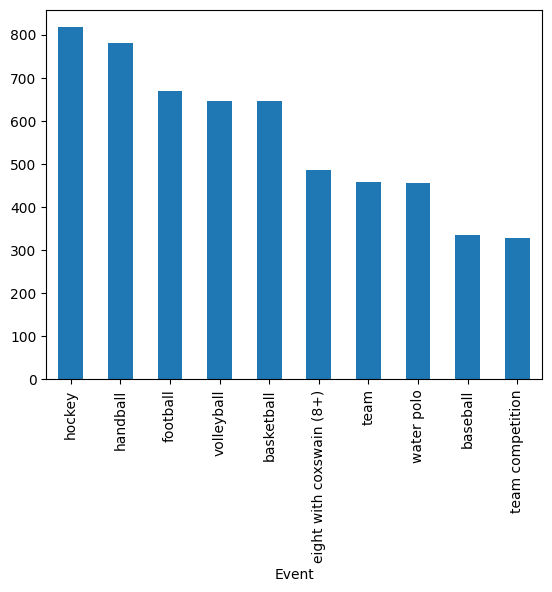

 Categorical Column:Athlete


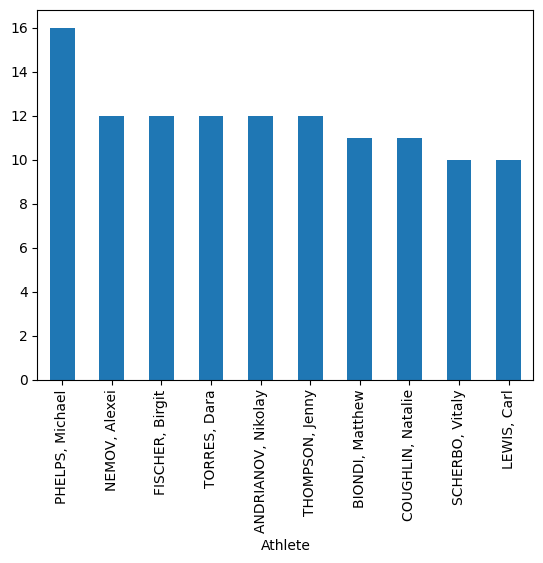

 Categorical Column:Gender


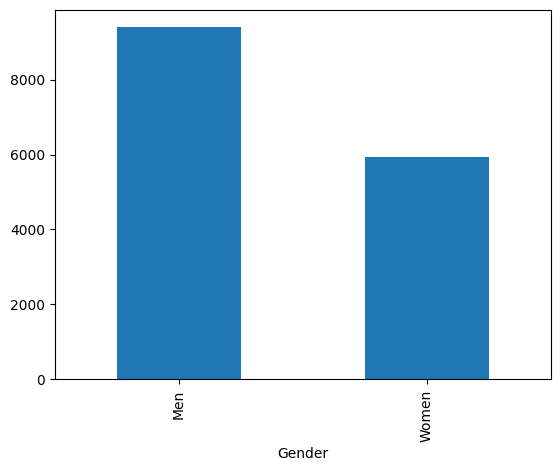

 Categorical Column:Country_Code


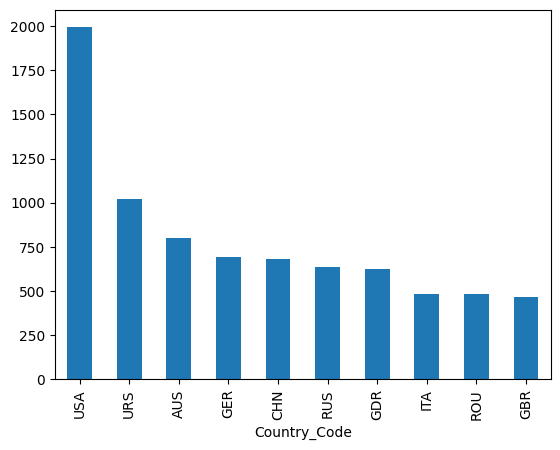

 Categorical Column:Country


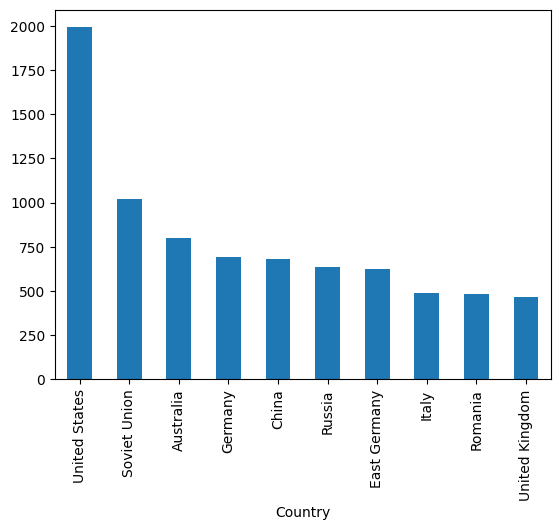

 Categorical Column:Event_gender


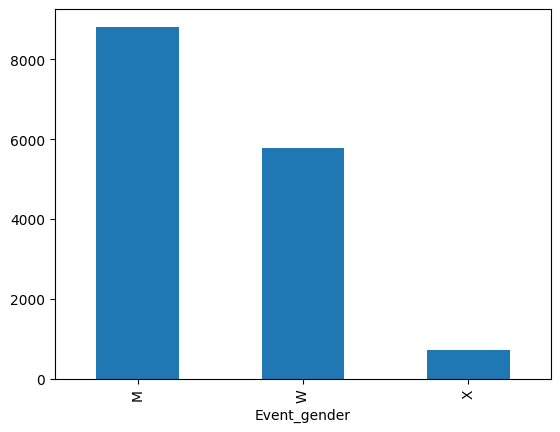

In [27]:
for i in X.select_dtypes(['object']):
    print(f" Categorical Column:{i}")
    plt.figure()

    X[i].value_counts().head(10).plot(kind='bar')
    plt.show()

 Categorical Column:City


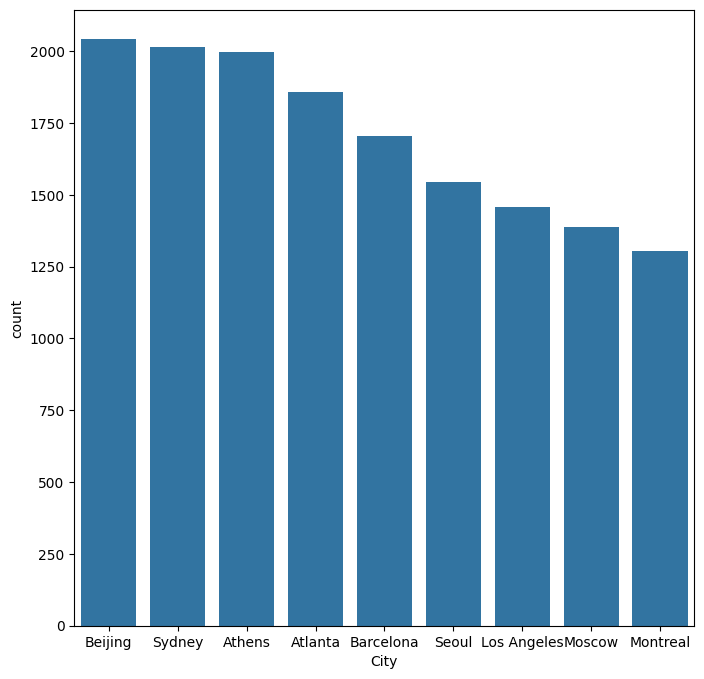

 Categorical Column:Sport


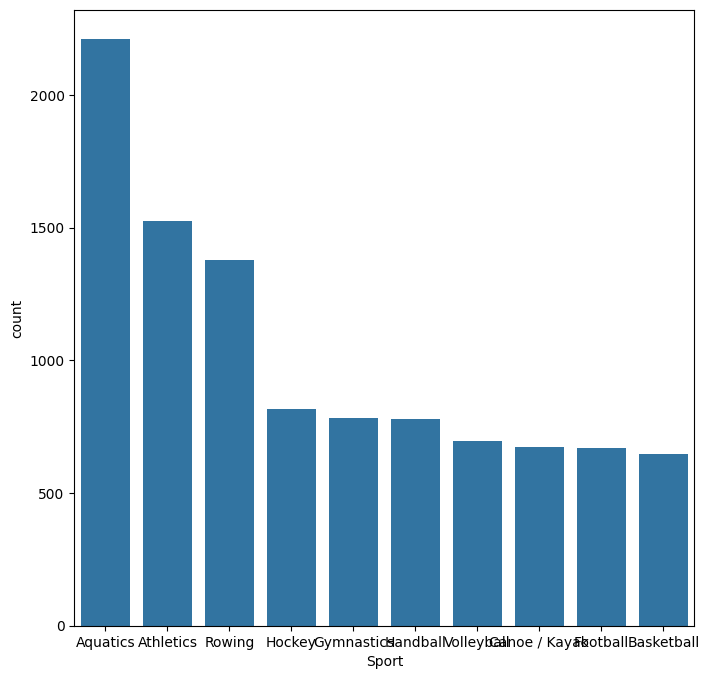

 Categorical Column:Discipline


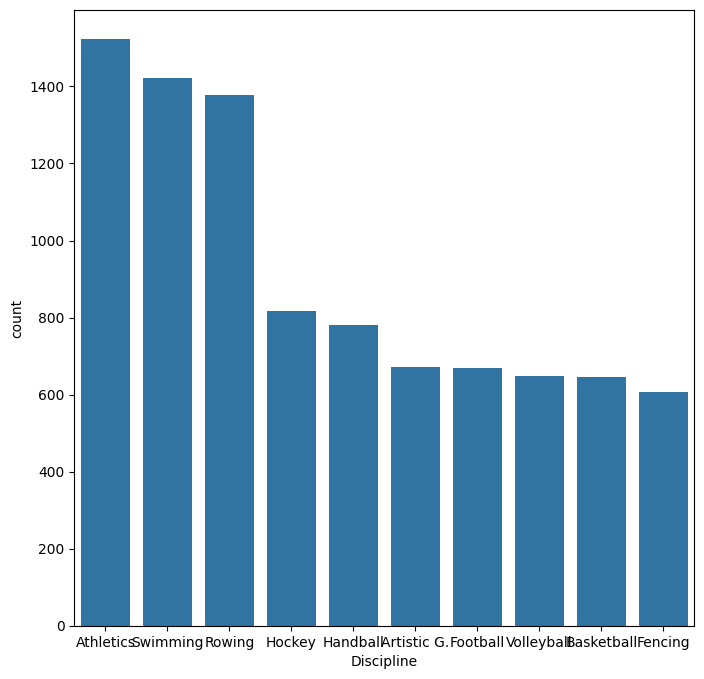

 Categorical Column:Event


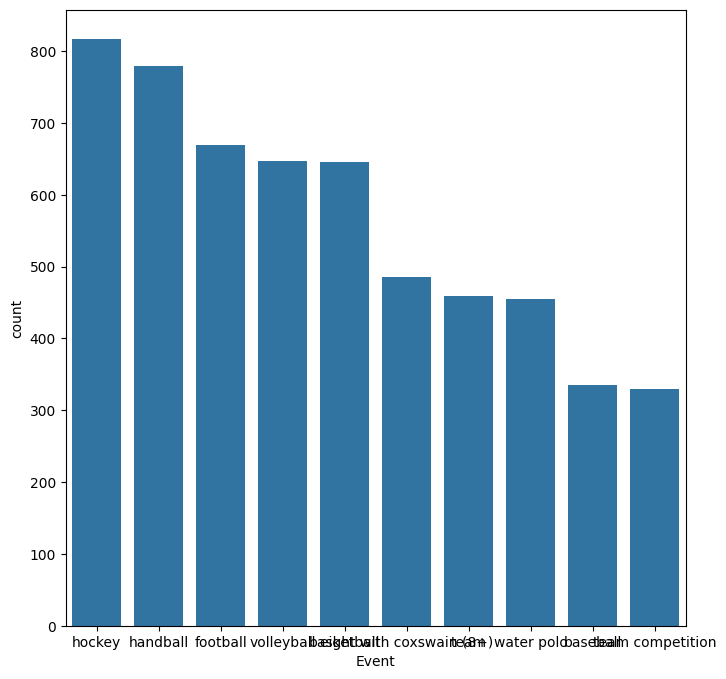

 Categorical Column:Athlete


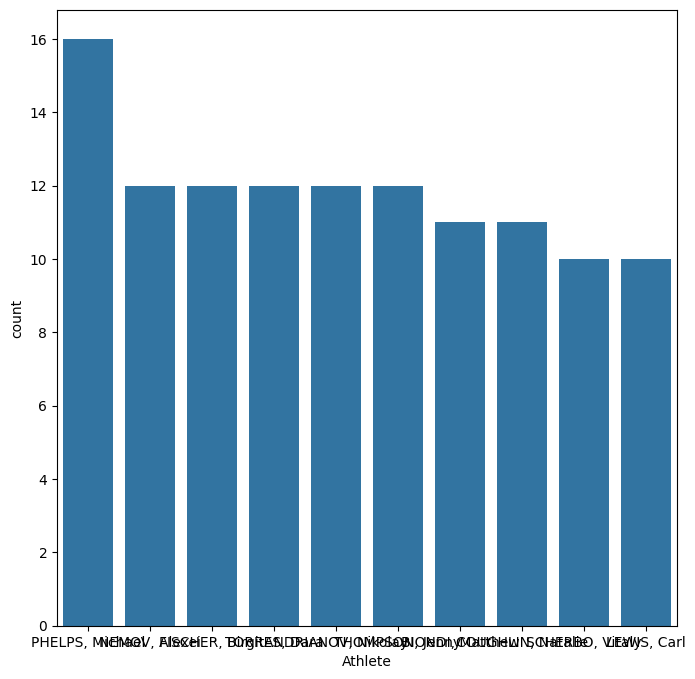

 Categorical Column:Gender


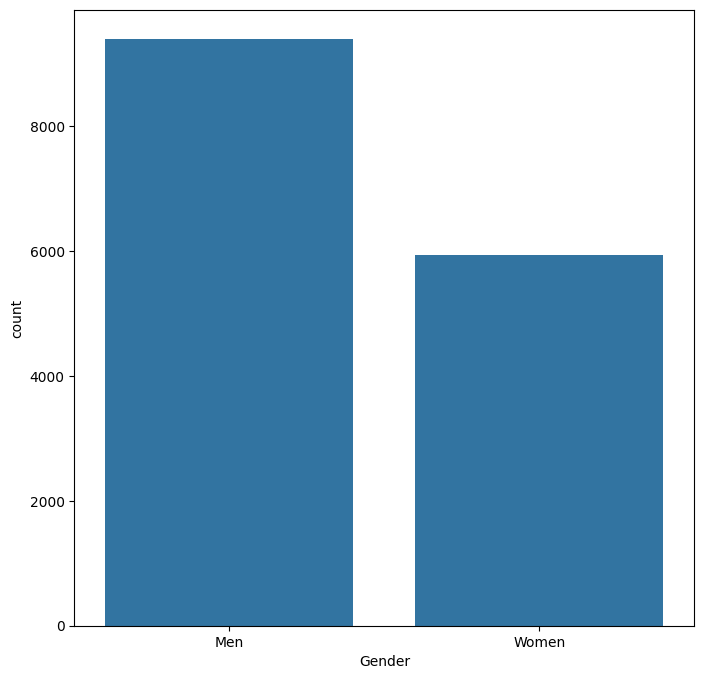

 Categorical Column:Country_Code


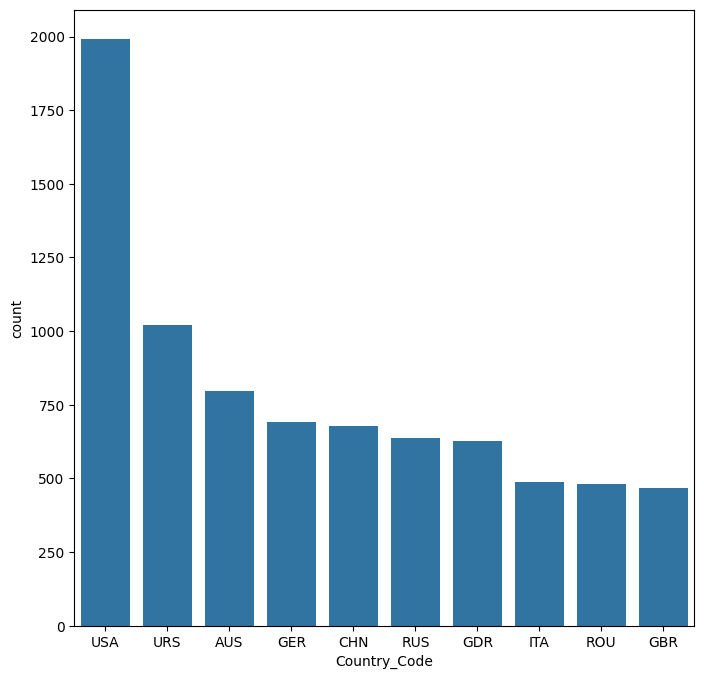

 Categorical Column:Country


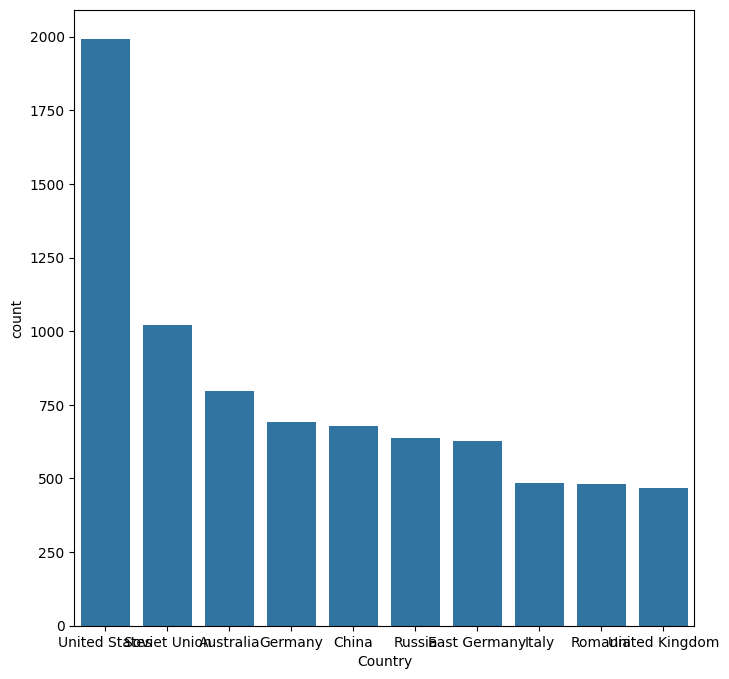

 Categorical Column:Event_gender


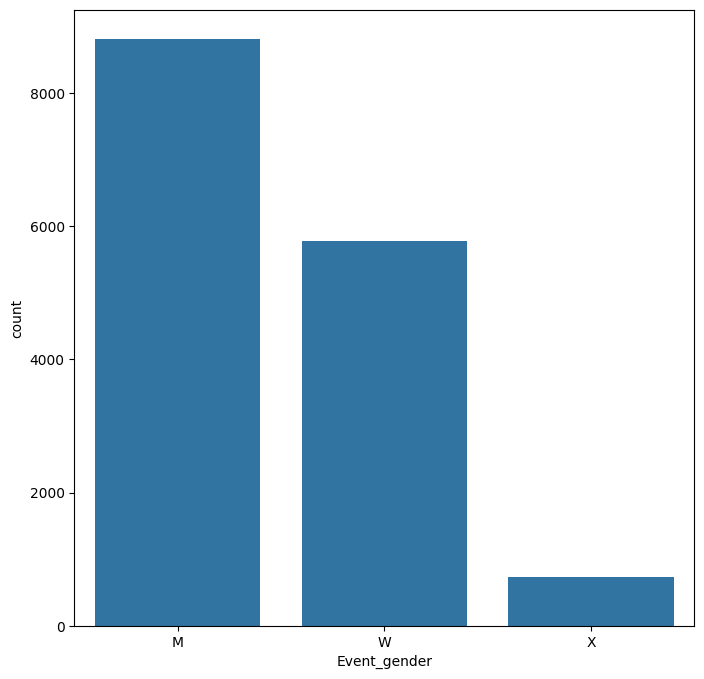

In [28]:
for i in X.select_dtypes(['object']):
    print(f" Categorical Column:{i}")
    plt.figure(figsize=(8,8))
    sns.barplot(X[i].value_counts().head(10))
    plt.show()

In [29]:
X['Event'].nunique()

293

In [30]:
X['Country'].value_counts()

Country
United States    1992
Soviet Union     1021
Australia         798
Germany           691
China             679
                 ... 
Panama              1
Mauritius           1
Sudan               1
Togo                1
Afghanistan         1
Name: count, Length: 127, dtype: int64

In [31]:
##  No of unique Categories in Categorical Columns
X.nunique()

City                9
Year                9
Sport              28
Discipline         41
Event             293
Athlete         11337
Gender              2
Country_Code      128
Country           127
Event_gender        3
dtype: int64

In [32]:
for col in X:
    print(f"No of categories in {col} is {X[col].nunique()}")

No of categories in City is 9
No of categories in Year is 9
No of categories in Sport is 28
No of categories in Discipline is 41
No of categories in Event is 293
No of categories in Athlete is 11337
No of categories in Gender is 2
No of categories in Country_Code is 128
No of categories in Country is 127
No of categories in Event_gender is 3


In [33]:
df['Sport'].unique()

array(['Aquatics', 'Archery', 'Athletics', 'Basketball', 'Boxing',
       'Canoe / Kayak', 'Cycling', 'Equestrian', 'Fencing', 'Football',
       'Gymnastics', 'Handball', 'Hockey', 'Judo', 'Modern Pentathlon',
       'Rowing', 'Sailing', 'Shooting', 'Volleyball', 'Weightlifting',
       'Wrestling', 'Table Tennis', 'Tennis', 'Badminton', 'Baseball',
       'Softball', 'Taekwondo', 'Triathlon'], dtype=object)

In [34]:
df['Event_gender'].unique()

array(['W', 'M', 'X'], dtype=object)

## Too much unique features and high sparsity
'''A sparse feature is one where:

Most categories appear very few times

Many values occur once or twice

There is little repetition '''

In [35]:
X_updated=X
X_updated=X.drop(columns=['Event','Athlete','Country_Code'])

In [36]:
X_updated

,City,Year,Sport,Discipline,Gender,Country,Event_gender
0,Montreal,1976,Aquatics,Diving,Women,East Germany,W
1,Montreal,1976,Aquatics,Diving,Men,Soviet Union,M
2,Montreal,1976,Aquatics,Diving,Men,United States,M
3,Montreal,1976,Aquatics,Diving,Men,Italy,M
4,Montreal,1976,Aquatics,Diving,Women,United States,W
...,...,...,...,...,...,...,...
15428,Beijing,2008,Wrestling,Wrestling Gre-R,Men,France,M
15429,Beijing,2008,Wrestling,Wrestling Gre-R,Men,Georgia,M
15430,Beijing,2008,Wrestling,Wrestling Gre-R,Men,Azerbaijan,M
15431,Beijing,2008,Wrestling,Wrestling Gre-R,Men,France,M


In [37]:
X_updated.columns

Index(['City', 'Year', 'Sport', 'Discipline', 'Gender', 'Country',
       'Event_gender'],
      dtype='object')

In [38]:
X_updated.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15316 entries, 0 to 15432
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   City          15316 non-null  object
 1   Year          15316 non-null  int64 
 2   Sport         15316 non-null  object
 3   Discipline    15316 non-null  object
 4   Gender        15316 non-null  object
 5   Country       15316 non-null  object
 6   Event_gender  15316 non-null  object
dtypes: int64(1), object(6)
memory usage: 957.2+ KB


## Columns seperation with respect to  various Data Types

## Numerical columns and labels encoding 

In [39]:
numerical_cols=X_updated.select_dtypes(['int64'])
numerical_labels=X_updated.select_dtypes(['int64']).columns.tolist()

In [40]:
numerical_labels

['Year']

## Categorical columns and labels encoding 

In [41]:
categorical_cols=X_updated.select_dtypes(['object'])
categorical_labels=X_updated.select_dtypes(['object']).columns.tolist()

In [42]:
categorical_cols

,City,Sport,Discipline,Gender,Country,Event_gender
0,Montreal,Aquatics,Diving,Women,East Germany,W
1,Montreal,Aquatics,Diving,Men,Soviet Union,M
2,Montreal,Aquatics,Diving,Men,United States,M
3,Montreal,Aquatics,Diving,Men,Italy,M
4,Montreal,Aquatics,Diving,Women,United States,W
...,...,...,...,...,...,...
15428,Beijing,Wrestling,Wrestling Gre-R,Men,France,M
15429,Beijing,Wrestling,Wrestling Gre-R,Men,Georgia,M
15430,Beijing,Wrestling,Wrestling Gre-R,Men,Azerbaijan,M
15431,Beijing,Wrestling,Wrestling Gre-R,Men,France,M


In [43]:
categorical_labels

['City', 'Sport', 'Discipline', 'Gender', 'Country', 'Event_gender']

## Column Transformer is used to encode columns simultanously

In [44]:
preprocessor=ColumnTransformer(
    
    transformers=[
        ('One Hot Encoding',OneHotEncoder(handle_unknown='ignore'),categorical_labels),
        ('Numerical Encoding',StandardScaler(),numerical_labels)
    ]
)

In [45]:
preprocessor

ColumnTransformer(transformers=[('One Hot Encoding',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['City', 'Sport', 'Discipline', 'Gender',
                                  'Country', 'Event_gender']),
                                ('Numerical Encoding', StandardScaler(),
                                 ['Year'])])

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

In [47]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, solver='lbfgs' ),

    'K Neighbors Classifier': KNeighborsClassifier(
        n_neighbors=8, weights='distance'),

    'Support Vector Machines': SVC(
        kernel='rbf'),

    'Decision Tree Classifier': DecisionTreeClassifier(
        criterion='gini',
        max_depth=9,
        min_samples_split=6,
        min_samples_leaf=3,
        random_state=43
    ),

    'Random Forest Classifier': RandomForestClassifier(
        n_estimators=200,
        max_features='sqrt',
        random_state=43,
        n_jobs=-1
    )
}

In [48]:
models

{'Logistic Regression': LogisticRegression(max_iter=1000),
 'K Neighbors Classifier': KNeighborsClassifier(n_neighbors=8, weights='distance'),
 'Support Vector Machines': SVC(),
 'Decision Tree Classifier': DecisionTreeClassifier(max_depth=9, min_samples_leaf=3, min_samples_split=6,
                        random_state=43),
 'Random Forest Classifier': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=43)}

In [49]:
X_updated.head(4)

,City,Year,Sport,Discipline,Gender,Country,Event_gender
0,Montreal,1976,Aquatics,Diving,Women,East Germany,W
1,Montreal,1976,Aquatics,Diving,Men,Soviet Union,M
2,Montreal,1976,Aquatics,Diving,Men,United States,M
3,Montreal,1976,Aquatics,Diving,Men,Italy,M


In [50]:
y.value_counts()

Medal
0    5258
1    5042
2    5016
Name: count, dtype: int64

## **3.Dataset Splitting**

In [51]:
X_train,X_test,y_train,y_test=train_test_split(X_updated,y,test_size=0.3,random_state=43)

In [52]:
X_train.shape

(10721, 7)

In [53]:
X_test.shape

(4595, 7)

In [54]:
y_train.shape

(10721,)

## Pipeline Building

In [55]:
models.items()

dict_items([('Logistic Regression', LogisticRegression(max_iter=1000)), ('K Neighbors Classifier', KNeighborsClassifier(n_neighbors=8, weights='distance')), ('Support Vector Machines', SVC()), ('Decision Tree Classifier', DecisionTreeClassifier(max_depth=9, min_samples_leaf=3, min_samples_split=6,
                       random_state=43)), ('Random Forest Classifier', RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=43))])

In [56]:
results=[]
for model_name,model in models.items():
    print(f"Model name is :{model_name}")

    pipeline=Pipeline(steps=[
        ('Preprocessing',preprocessor),
        ('Model',model)
    ]
    )
    pipeline.fit(X_train,y_train)
    y_pred=pipeline.predict(X_test)
    acc = f1_score(y_test, y_pred,average='macro')
    results.append({'Model name':model_name,
                   'Accuracy Score':acc
                   })
    

Model name is :Logistic Regression
Model name is :K Neighbors Classifier
Model name is :Support Vector Machines
Model name is :Decision Tree Classifier
Model name is :Random Forest Classifier


In [57]:
print(results)

[{'Model name': 'Logistic Regression', 'Accuracy Score': 0.40295805843691984}, {'Model name': 'K Neighbors Classifier', 'Accuracy Score': 0.6808761965155877}, {'Model name': 'Support Vector Machines', 'Accuracy Score': 0.602649730718991}, {'Model name': 'Decision Tree Classifier', 'Accuracy Score': 0.39095859870399613}, {'Model name': 'Random Forest Classifier', 'Accuracy Score': 0.6932276192843972}]


In [58]:
results_df=pd.DataFrame(results).sort_values(by='Accuracy Score',ascending=False)

## **4.Model Performance (Without Cross Validation)**

In [59]:
results_df

,Model name,Accuracy Score
4,Random Forest Classifier,0.693228
1,K Neighbors Classifier,0.680876
2,Support Vector Machines,0.602650
0,Logistic Regression,0.402958
3,Decision Tree Classifier,0.390959


## **5. Cross validation**

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=43
)

In [60]:
results_cross_val=[]
for model_name1,cross_val_model in models.items():
    print(f"Model name is :{model_name1}")

    pipeline_1=Pipeline(steps=[
        ('Preprocessing',preprocessor),
        ('Model',cross_val_model)
    ]
    )
    cv_scores = np.mean(cross_val_score(pipeline_1, X_updated, y, cv=5, scoring='f1_macro'))
    results_cross_val.append({'Model name':model_name1,
                   'Accuracy Score':cv_scores
                   })
    

Model name is :Logistic Regression
Model name is :K Neighbors Classifier
Model name is :Support Vector Machines
Model name is :Decision Tree Classifier
Model name is :Random Forest Classifier


 models={
    'Logistic Regression':LogisticRegression(max_iter=1000,solver='lbfgs',C=1.0
                                             ,n_jobs=-1),
    'K Neighbors Classifier':KNeighborsClassifier(n_neighbors=8,weights='distance'),
    'Support Vector Machines':SVC(kernel='poly'),
    'Decision Tree Classifier':DecisionTreeClassifier(splitter='best',criterion='gini',max_depth=7,
        min_samples_split=6,
        random_state=43),
    'Random Forest Classifier':RandomForestClassifier(n_estimators=150,criterion='entropy')
}

preprocessor=ColumnTransformer(
    
    transformers=[
        ('One Hot Encoding',OneHotEncoder(handle_unknown='ignore'),categorical_labels),
        ('Numerical Encoding',StandardScaler(),numerical_labels)
    ]
)

In [61]:
results_df_cross_val=pd.DataFrame(results_cross_val).sort_values(by='Accuracy Score',ascending=False)

## **6. Results after Cross Validation**

In [62]:
results_df_cross_val

,Model name,Accuracy Score
4,Random Forest Classifier,0.391530
2,Support Vector Machines,0.385471
1,K Neighbors Classifier,0.373352
0,Logistic Regression,0.355662
3,Decision Tree Classifier,0.305094


In [63]:
y_test

10002    2
2883     2
7330     2
4736     0
5960     2
        ..
12406    2
2739     1
11440    2
12648    1
6815     1
Name: Medal, Length: 4595, dtype: int64

In [64]:
y_pred

array([2, 1, 1, ..., 2, 1, 0])

## **7.Confusion Matrix**

## **Bronze - 0 ,Gold is 1 , Silver is 2**

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
)





In [66]:
cm

array([[1091,  223,  238],
       [ 199, 1101,  211],
       [ 258,  279,  995]])

In [67]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Bronze', 'Gold', 'Silver']
)

## Out of 1552 actual Bronze medals:

✅ 1091 correctly predicted as Bronze

❌ 223 predicted as Gold

❌ 238 predicted as Silver

In [68]:
print(disp)

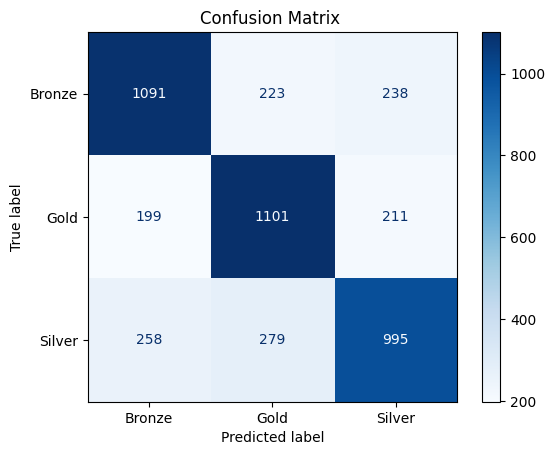

In [69]:
disp.plot(cmap='Blues')
plt.title('Confusion Matrix ')
plt.show()